# Блок 6. Погружение в Python и анализ данных
## Занятие 10. Группировка, агрегация и аналитические отчёты в Pandas

## Цель занятия

На прошлом занятии мы изучили очистку данных:

- пропуски;
- дубликаты;
- заполнение пустых значений;
- подготовку данных к анализу.

Сначала изучите SOLVED-ноутбук вместе с преподавателем. Затем выполните TODO-ноутбук самостоятельно.

Сегодня изучаем одну из самых важных тем Pandas:

```python
groupby()
```

На занятии научимся:

- группировать данные по категориям;
- считать количество объектов в группе;
- считать среднее, минимум и максимум;
- строить аналитические отчёты;
- сортировать результаты;
- визуализировать группировки.

---

## Что такое группировка

Группировка отвечает на вопросы:

- какая категория самая популярная;
- где средняя цена выше;
- какой регион даёт больше продаж;
- какая группа клиентов приносит больше прибыли;
- какая категория товаров самая доходная.

Пример:

```python
df.groupby("category")["price"].mean()
```

---

## Датасет занятия

Используем датасет California Housing:

```text
https://raw.githubusercontent.com/ageron/handson-ml/master/datasets/housing/housing.csv
```

Ключевая категориальная колонка:

```python
ocean_proximity
```

Она показывает близость района к океану.

---

## Колонки датасета на русском языке

| Колонка | Описание |
|---|---|
| longitude | долгота района |
| latitude | широта района |
| housing_median_age | медианный возраст домов |
| total_rooms | общее количество комнат |
| total_bedrooms | общее количество спален |
| population | население района |
| households | количество домохозяйств |
| median_income | медианный доход |
| median_house_value | медианная стоимость жилья |
| ocean_proximity | близость к океану |

---

## Прикладное значение

Группировка используется:

- в продажах;
- в CRM;
- в HR-аналитике;
- в недвижимости;
- в финансах;
- в медицинских и спортивных данных;
- в подготовке отчётов для руководителей.

---

## Связь с дипломом

В дипломном проекте группировка нужна для аналитических отчётов:

- средняя цена по району;
- средний score по группе кандидатов;
- продажи по категории;
- калории по типу тренировки;
- доход по месяцу;
- количество заявок по статусу.

---

## GitHub

```bash
git checkout main
git pull origin main
git checkout -b feature/block6-lesson10-groupby-reports

git add .
git commit -m "feat: add pandas groupby reports lesson"
git push -u origin feature/block6-lesson10-groupby-reports
```

## Ячейка 1. TODO: импорт библиотек

### Алгоритм

1. Импортируйте `pandas`.
2. Импортируйте `matplotlib.pyplot`.
3. Выведите сообщение.
4. Добавьте assert.

In [11]:
# TODO: импортируйте pandas как pd
import pandas as pd
# TODO: импортируйте matplotlib.pyplot как plt
import matplotlib.pyplot as plt
from IPython.core.magics import display

# TODO: выведите сообщение
print("Assemblies loaded")
# TODO: assert
assert pd is not None
assert plt is not None

Assemblies loaded


## Ячейка 2. TODO: загрузка датасета

### Алгоритм

1. Создайте переменную `url`.
2. Загрузите данные через `pd.read_csv`.
3. Покажите первые строки.
4. Проверьте наличие колонки `ocean_proximity`.

In [12]:
# TODO: создайте url
url = "https://raw.githubusercontent.com/ageron/handson-ml/master/datasets/housing/housing.csv"

# TODO: загрузите df
df = pd.read_csv(url)
# TODO: покажите df.head()
display(df.head())
# TODO: assert len(df) > 0
assert len(df) > 0
target_col = "ocean_proximity"
# TODO: assert "ocean_proximity" in df.columns
assert target_col in df.columns

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


## Ячейка 3. TODO: первичное изучение данных

### Алгоритм

1. Выведите размер таблицы.
2. Выведите список колонок.
3. Выведите уникальные значения `ocean_proximity`.
4. Выведите пропуски.

In [13]:
# TODO: выведите df.shape
print(df.shape)
# TODO: выведите df.columns.tolist()
print(df.columns.tolist())
# TODO: выведите df[target_col].unique()
print("Ocean proximity:", ", ".join(df[target_col].unique()))
# TODO: выведите df.isna().sum()
print("Empty rows count:")
display(df.isna().sum())
# TODO: assert
assert df[target_col].nunique() > 1

(20640, 10)
['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'median_house_value', 'ocean_proximity']
Ocean proximity: NEAR BAY, <1H OCEAN, INLAND, NEAR OCEAN, ISLAND
Empty rows count:


longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

## Ячейка 4. TODO: количество районов по категориям

### Алгоритм

1. Сгруппируйте данные по `ocean_proximity`.
2. Посчитайте количество строк.
3. Отсортируйте результат.
4. Проверьте сумму.

In [15]:
# TODO: создайте count_report
count_report = (
    df.groupby(target_col).size().sort_values(ascending=False)
)
# TODO: выведите count_report
display(count_report)
# TODO: assert count_report.sum() == len(df)
assert count_report.sum() == len(df)

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
dtype: int64

## Ячейка 5. TODO: средняя стоимость жилья по категориям

### Алгоритм

1. Сгруппируйте по `ocean_proximity`.
2. Выберите `median_house_value`.
3. Посчитайте среднее.
4. Отсортируйте результат.

In [18]:
# TODO: создайте mean_price_report
mean_price_report = (
    df.groupby(target_col)["median_house_value"].mean().sort_values(ascending=False)
)
# TODO: выведите mean_price_report
print(mean_price_report)
# TODO: assert
assert len(mean_price_report) > 0
assert mean_price_report.iloc[0] > mean_price_report.iloc[-1]

ocean_proximity
ISLAND        380440.000000
NEAR BAY      259212.311790
NEAR OCEAN    249433.977427
<1H OCEAN     240084.285464
INLAND        124805.392001
Name: median_house_value, dtype: float64


## Ячейка 6. TODO: несколько агрегатов

### Алгоритм

1. Используйте `groupby`.
2. Используйте `.agg(["count", "mean", "min", "max"])`.
3. Отсортируйте по `mean`.
4. Покажите отчёт.

In [20]:
# TODO: создайте price_agg_report
price_agg_report = (
    df.groupby(target_col)["median_house_value"].agg(["count", "mean", "min", "max"])
    .sort_values(by="mean", ascending=False)
)
# TODO: покажите price_agg_report
display(price_agg_report)
# TODO: assert "mean" in price_agg_report.columns
assert "mean" in price_agg_report
assert "max" in price_agg_report

,count,mean,min,max
ocean_proximity,,,,
ISLAND,5,380440.000000,287500.0,450000.0
NEAR BAY,2290,259212.311790,22500.0,500001.0
NEAR OCEAN,2658,249433.977427,22500.0,500001.0
<1H OCEAN,9136,240084.285464,17500.0,500001.0
INLAND,6551,124805.392001,14999.0,500001.0


## Ячейка 7. TODO: группировка по доходу и цене

### Алгоритм

1. Сгруппируйте по `ocean_proximity`.
2. Выберите колонки `median_income` и `median_house_value`.
3. Посчитайте среднее.
4. Отсортируйте по стоимости жилья.

In [25]:
# TODO: создайте income_price_report
income_price_report = (
    df.groupby(target_col)[["median_income", "median_house_value"]]
    .agg("mean").sort_values(by="median_house_value", ascending=False)
)
# TODO: покажите income_price_report
display(income_price_report)
# TODO: assert
assert income_price_report["median_house_value"].iloc[0] > income_price_report["median_house_value"].iloc[1]

,median_income,median_house_value
ocean_proximity,,
ISLAND,2.744420,380440.000000
NEAR BAY,4.172885,259212.311790
NEAR OCEAN,4.005785,249433.977427
<1H OCEAN,4.230682,240084.285464
INLAND,3.208996,124805.392001


## Ячейка 8. TODO: визуализация отчёта

### Алгоритм

1. Постройте bar chart по `mean_price_report`.
2. Добавьте заголовок.
3. Добавьте подписи осей.
4. Добавьте сетку.

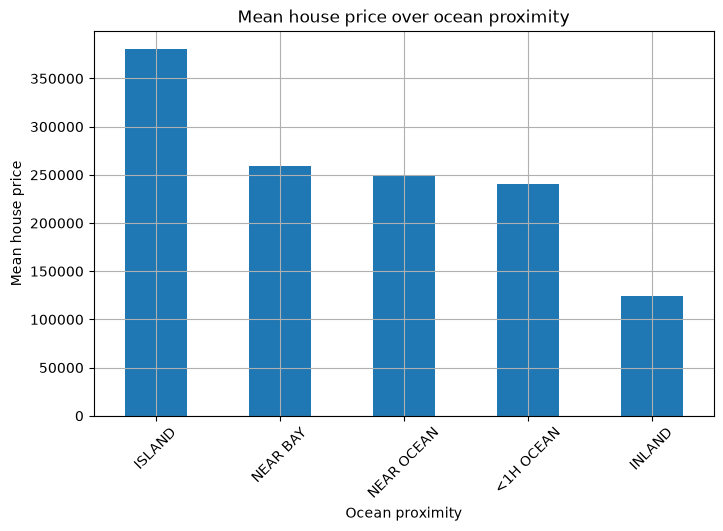

In [27]:
# TODO: создайте figure
plt.figure(figsize=(8, 5))
# TODO: постройте mean_price_report.plot(kind="bar")
mean_price_report.plot(kind="bar")
# TODO: добавьте title, xlabel, ylabel
plt.title("Mean house price over ocean proximity")
plt.xlabel("Ocean proximity")
plt.ylabel("Median house price")
# TODO: добавьте xticks rotation
plt.xticks(rotation=45)
# TODO: добавьте grid
plt.grid(True)
# TODO: show()
plt.show()
# TODO: assert

assert len(mean_price_report) > 0

## Ячейка 9. TODO: функция для группового отчёта

### Алгоритм

1. Создайте функцию `create_group_report`.
2. Передайте DataFrame, колонку группы и числовую колонку.
3. Верните отчёт с count, mean, min, max.
4. Проверьте результат.

In [30]:
# TODO: создайте функцию create_group_report(dataframe, group_column, value_column)
def create_group_report(dataframe: pd.DataFrame, group_col: str, values_col: str | [str],
                        aggs: str | [str] = ["count", "mean", "min", "max"]):
    # TODO: внутри создайте report
    # TODO: верните report
    return dataframe.groupby(group_col)[values_col].agg(aggs)


# TODO: вызовите функцию

report = create_group_report(df, target_col, ["median_house_value", "housing_median_age"])

# TODO: покажите custom_report
display(report)
# TODO: assert

median_house_value                                     \
                             count           mean       min       max   
ocean_proximity                                                         
<1H OCEAN                     9136  240084.285464   17500.0  500001.0   
INLAND                        6551  124805.392001   14999.0  500001.0   
ISLAND                           5  380440.000000  287500.0  450000.0   
NEAR BAY                      2290  259212.311790   22500.0  500001.0   
NEAR OCEAN                    2658  249433.977427   22500.0  500001.0   

                housing_median_age                         
                             count       mean   min   max  
ocean_proximity                                            
<1H OCEAN                     9136  29.279225   2.0  52.0  
INLAND                        6551  24.271867   1.0  52.0  
ISLAND                           5  42.400000  27.0  52.0  
NEAR BAY                      2290  37.730131   2.0  52.0  
NEAR OCEAN                    2658  29.347254   2.0  52.0

## Ячейка 10. TODO: мини-проект занятия

### Алгоритм

1. Найдите категорию с самой высокой средней ценой.
2. Создайте словарь `project_report`.
3. Создайте список из 5 выводов.
4. Выведите результаты.

In [31]:
# TODO: создайте top_category
top_category = mean_price_report.idxmax()
# TODO: создайте top_value
top_value = mean_price_report.max()
# TODO: создайте project_report
project_report = {
    "rows": len(df),
    "categories_count": df[target_col].nunique(),
    "top_category_by_price": top_category,
    "top_mean_price": top_value
}
# TODO: выведите project_report
print("Report:")
for k, v in project_report.items():
    print(k, ":", v)
# TODO: создайте conclusions из 5 выводов

conclusions = [
    "Группировка помогает сравнивать категории.",
    "Средняя стоимость жилья зависит от близости к океану.",
    "Pandas groupby позволяет быстро строить аналитические отчёты.",
    "Агрегации count, mean, min, max полезны для бизнес-аналитики.",
    "Такой подход можно использовать в дипломном проекте."
]

print()
print("Выводы:")
for item in conclusions:
    print("-", item)

assert project_report["rows"] > 1000
assert len(conclusions) == 5
# TODO: выведите conclusions

# TODO: assert

Report:
rows : 20640
categories_count : 5
top_category_by_price : ISLAND
top_mean_price : 380440.0

Выводы:
- Группировка помогает сравнивать категории.
- Средняя стоимость жилья зависит от близости к океану.
- Pandas groupby позволяет быстро строить аналитические отчёты.
- Агрегации count, mean, min, max полезны для бизнес-аналитики.
- Такой подход можно использовать в дипломном проекте.


# Итог TODO-задания

Покажите преподавателю:

- `groupby`;
- `size`;
- `agg`;
- `count`;
- `mean`;
- `min`;
- `max`;
- график группировки;
- функцию отчёта;
- итоговые выводы.

## GitHub

```bash
git add .
git commit -m "feat: complete pandas groupby reports todo"
git push -u origin feature/block6-lesson10-groupby-reports
```